In [ ]:
!pip -q install lime
!pip -q install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import cv2
import zipfile
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    average_precision_score
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
ZIP_PATH = "/content/Potato.zip"

IMG_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 30


In [ ]:
def segment_leaf(image):

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower = np.array([25,40,40])

    upper = np.array([95,255,255])

    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5,5), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    result = cv2.bitwise_and(image, image, mask=mask)

    return result

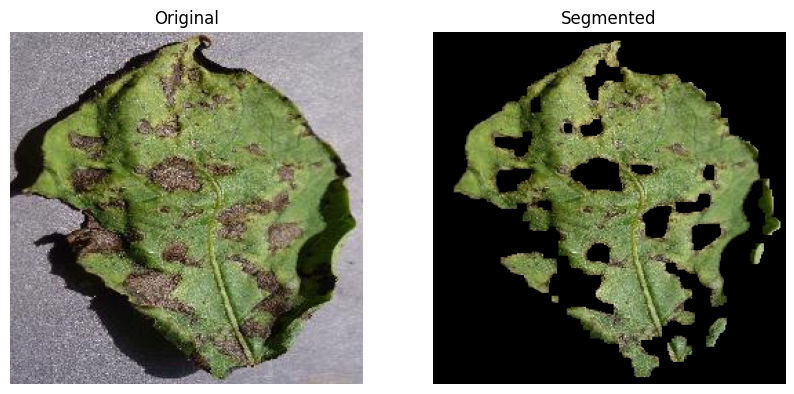

In [ ]:
with zipfile.ZipFile(ZIP_PATH,"r") as z:

    imgs = [f for f in z.namelist()

            if f.lower().endswith((".jpg",".jpeg",".png"))]

    sample = imgs[0]

    data = z.read(sample)

    arr = np.frombuffer(data,np.uint8)

    img = cv2.imdecode(arr,cv2.IMREAD_COLOR)

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

seg = segment_leaf(img)

plt.figure(figsize=(10,5))

plt.subplot(121)

plt.imshow(img)

plt.title("Original")

plt.axis("off")

plt.subplot(122)

plt.imshow(seg)

plt.title("Segmented")

plt.axis("off")

plt.show()

In [ ]:
with zipfile.ZipFile(ZIP_PATH,"r") as z:

    files = z.namelist()

print("Total Files :", len(files))

print()

for i in files[:20]:

    print(i)

Total Files : 2156

Potato/
Potato/Potato___Early_blight/
Potato/Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG
Potato/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG
Potato/Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG
Potato/Potato___Early_blight/00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG
Potato/Potato___Early_blight/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG
Potato/Potato___Early_blight/02578b86-b234-4ac0-9bc3-691b5610e2bf___RS_Early.B 7562.JPG
Potato/Potato___Early_blight/0267d4ca-522e-4ca0-b1a2-ce925e5b54a2___RS_Early.B 7020.JPG
Potato/Potato___Early_blight/028f9b73-142f-499a-9c7b-d7c1ed5e5506___RS_Early.B 8546.JPG
Potato/Potato___Early_blight/034959c1-f1e8-4a79-a6d5-3c1d14efa2f3___RS_Early.B 7136.JPG
Potato/Potato___Early_blight/03b0d3c1-b5b0-48f4-98aa-f8904670290f___RS_Early.B 7051.JPG
Potato/Potato___Early_blight/042135e2-e126-4900-9212-d42d900b8

In [ ]:
# ==========================================================
# Read Complete Dataset From ZIP
# ==========================================================

images = []
labels = []

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("Total image files found:", len(image_files))

    for file in image_files:

        if file.endswith("/"):
            continue

        if "__MACOSX" in file:
            continue

        parts = file.replace("\\", "/").split("/")

        # Skip images not inside a class folder
        if len(parts) < 2:
            continue

        class_name = parts[-2]

        try:

            img_bytes = z.read(file)

            img_array = np.frombuffer(img_bytes, np.uint8)

            img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = segment_leaf(img)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images.append(img)

            labels.append(class_name)

        except Exception:
            continue

print("Images Loaded :", len(images))

Total image files found: 2152
Images Loaded : 2152


In [ ]:
# ==========================================================
# Convert To NumPy
# ==========================================================

images = np.array(images, dtype=np.float32)

labels = np.array(labels)

print(images.shape)

print(labels.shape)

(2152, 224, 224, 3)
(2152,)


In [ ]:
# ==========================================================
# Dataset Summary
# ==========================================================

unique_classes = sorted(np.unique(labels))

print("Classes Found:\n")

for cls in unique_classes:

    print(cls)

print()

print("Number of Classes :", len(unique_classes))

Classes Found:

Potato___Early_blight
Potato___Late_blight
Potato___healthy

Number of Classes : 3


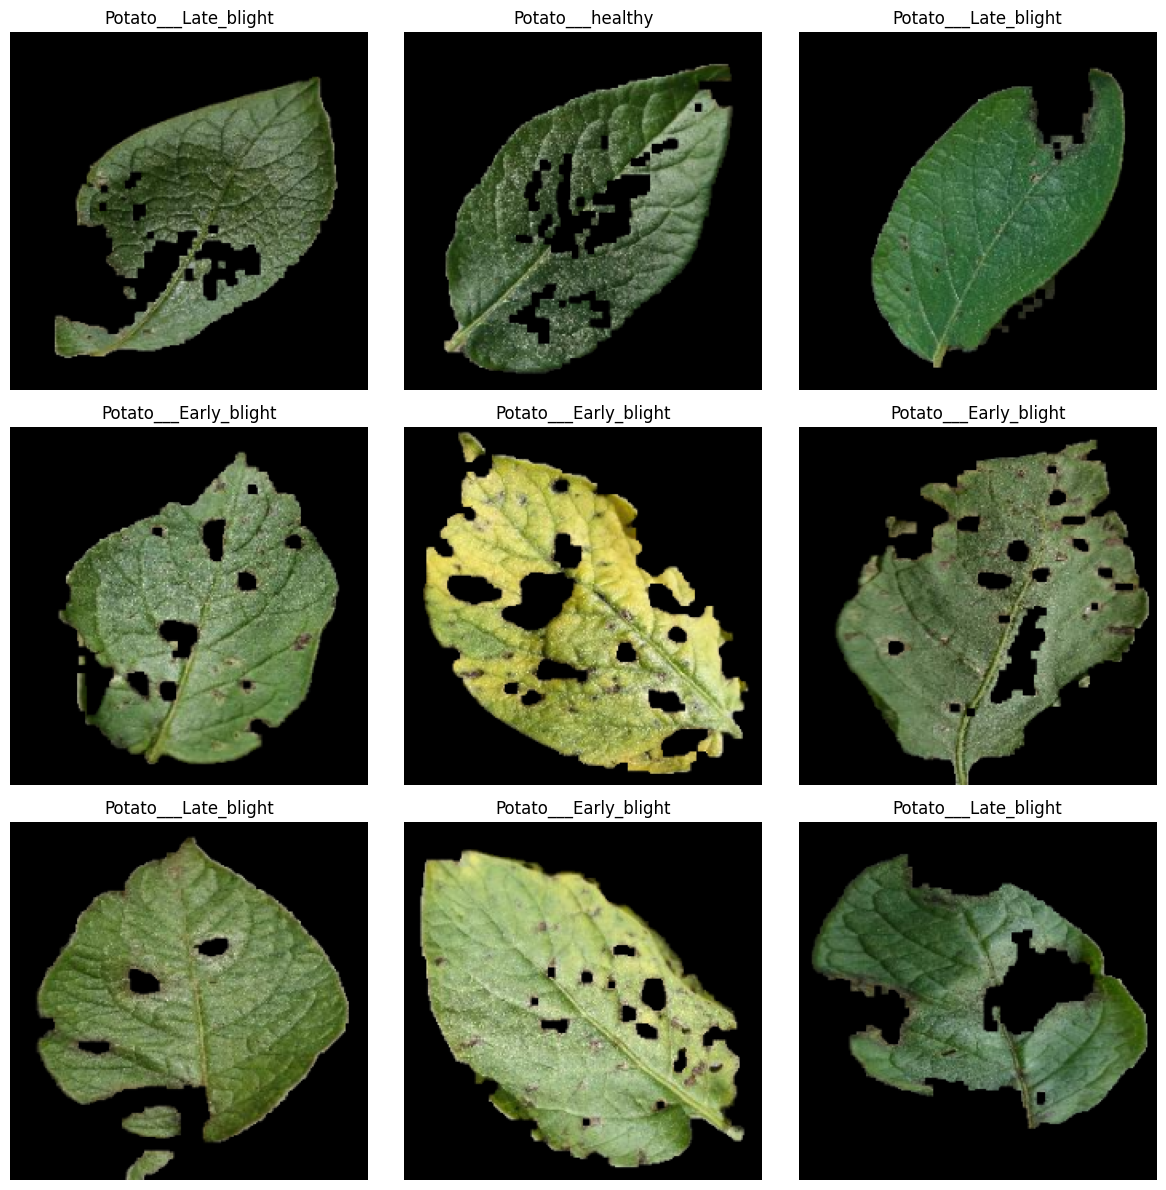

In [ ]:
# ==========================================================
# Display Random Images
# ==========================================================

plt.figure(figsize=(12,12))

for i in range(9):

    idx = random.randint(0, len(images)-1)

    plt.subplot(3,3,i+1)

    plt.imshow(images[idx].astype(np.uint8))

    plt.title(labels[idx])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# MobileNetV2 Preprocessing
# ==========================================================

images = tf.keras.applications.mobilenet_v2.preprocess_input(images)

print(images.shape)

(2152, 224, 224, 3)


In [ ]:
# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

NUM_CLASSES = len(encoder.classes_)

labels_encoded = to_categorical(
    labels_encoded,
    NUM_CLASSES
)

print("Classes")

print(encoder.classes_)

print()

print("Number of Classes :", NUM_CLASSES)

Classes
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

Number of Classes : 3


In [ ]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    images,

    labels_encoded,

    test_size=0.20,

    random_state=42,

    stratify=np.argmax(labels_encoded, axis=1),

    shuffle=True

)

print("Training :", X_train.shape)

print("Testing  :", X_test.shape)

Training : (1721, 224, 224, 3)
Testing  : (431, 224, 224, 3)


In [ ]:
# ==========================================================
# Data Augmentation
# ==========================================================

train_datagen = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    fill_mode="nearest"

)

test_datagen = ImageDataGenerator()

In [ ]:
# ==========================================================
# Data Generators
# ==========================================================

train_generator = train_datagen.flow(

    X_train,

    y_train,

    batch_size=BATCH_SIZE,

    shuffle=True

)

test_generator = test_datagen.flow(

    X_test,

    y_test,

    batch_size=BATCH_SIZE,

    shuffle=False

)

print("Training Batches :", len(train_generator))

print("Testing Batches  :", len(test_generator))

Training Batches : 54
Testing Batches  : 14


In [ ]:
# ==========================================================
# Class Distribution
# ==========================================================

print("Training Distribution\n")

train_labels = np.argmax(y_train, axis=1)

for i, cls in enumerate(encoder.classes_):

    print(cls, ":", np.sum(train_labels == i))

print("\nTesting Distribution\n")

test_labels = np.argmax(y_test, axis=1)

for i, cls in enumerate(encoder.classes_):

    print(cls, ":", np.sum(test_labels == i))

Training Distribution

Potato___Early_blight : 800
Potato___Late_blight : 800
Potato___healthy : 121

Testing Distribution

Potato___Early_blight : 200
Potato___Late_blight : 200
Potato___healthy : 31


In [ ]:
# ==========================================================
# ConViTX Hyperparameters
# ==========================================================

image_size = 224

patch_size = 7

num_patches = (image_size // patch_size) ** 2

projection_dim = 48

num_heads = 4

transformer_layers = 8

transformer_units = [

    projection_dim * 2,

    projection_dim

]

print("Number of patches :", num_patches)

Number of patches : 1024


In [ ]:
# ==========================================================
# MobileNetV2 Backbone
# ==========================================================

base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights="imagenet"

)

base_model.trainable = True

print("Backbone Loaded")

base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone Loaded


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
# ==========================================================
# MLP Block
# ==========================================================

def mlp(x, hidden_units, dropout_rate):

    for units in hidden_units:

        x = layers.Dense(
            units,
            activation=tf.nn.gelu
        )(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

    return x

In [ ]:
# ==========================================================
# Patch Layer
# ==========================================================

class Patches(layers.Layer):

    def __init__(self, patch_size, **kwargs):

        super().__init__(**kwargs)

        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(

            images=images,

            sizes=[1,self.patch_size,self.patch_size,1],

            strides=[1,self.patch_size,self.patch_size,1],

            rates=[1,1,1,1],

            padding="VALID"

        )

        patch_dim = patches.shape[-1]

        patches = tf.reshape(

            patches,

            [batch_size,-1,patch_dim]

        )

        return patches

    def get_config(self):

        config = super().get_config()

        config.update({

            "patch_size":self.patch_size

        })

        return config

In [ ]:
# ==========================================================
# Patch Encoder
# ==========================================================

class PatchEncoder(layers.Layer):

    def __init__(self,
                 num_patches,
                 projection_dim,
                 **kwargs):

        super().__init__(**kwargs)

        self.num_patches = num_patches

        self.projection_dim = projection_dim

        self.projection = layers.Dense(

            projection_dim

        )

        self.position_embedding = layers.Embedding(

            input_dim=num_patches,

            output_dim=projection_dim

        )

    def call(self, patches):

        positions = tf.range(

            start=0,

            limit=self.num_patches,

            delta=1

        )

        encoded = self.projection(

            patches

        ) + self.position_embedding(

            positions

        )

        return encoded

    def get_config(self):

        config = super().get_config()

        config.update({

            "num_patches":self.num_patches,

            "projection_dim":self.projection_dim

        })

        return config

In [ ]:
# ==========================================================
# SE Block
# ==========================================================

def se_block(inputs, ratio=4):

    channels = inputs.shape[-1]

    x = layers.GlobalAveragePooling2D()(inputs)

    x = layers.Reshape((1,1,channels))(x)

    x = layers.Dense(

        channels//ratio,

        activation="relu",

        kernel_initializer="he_normal"

    )(x)

    x = layers.Dense(

        channels,

        activation="sigmoid",

        kernel_initializer="he_normal"

    )(x)

    return layers.Multiply()([inputs,x])

In [ ]:
# ==========================================================
# CNN Feature Extraction
# ==========================================================

cnn_layers = base_model.get_layer(

    "block_6_project_BN"

).output

cnn_features = se_block(

    cnn_layers,

    ratio=4

)

print(cnn_features.shape)

(None, 14, 14, 64)


In [ ]:
# ==========================================================
# Patch Creation Test
# ==========================================================

patches = Patches(

    patch_size

)(base_model.input)

print(patches.shape)

(None, None, 147)


In [ ]:
# ==========================================================
# Patch Encoding Test
# ==========================================================

encoded_patches = PatchEncoder(

    num_patches,

    projection_dim

)(patches)

print(encoded_patches.shape)

(None, 1024, 48)


In [ ]:
# ==========================================================
# Vision Transformer Encoder
# ==========================================================

encoded = encoded_patches

for i in range(transformer_layers):

    x1 = layers.LayerNormalization(
        epsilon=1e-6,
        name=f"LN1_{i}"
    )(encoded)

    attention = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=0.1,
        name=f"MHA_{i}"
    )(x1, x1)

    x2 = layers.Add()([attention, encoded])

    x3 = layers.LayerNormalization(
        epsilon=1e-6,
        name=f"LN2_{i}"
    )(x2)

    x3 = mlp(
        x3,
        hidden_units=transformer_units,
        dropout_rate=0.1
    )

    encoded = layers.Add()([x3, x2])

vit_output = layers.LayerNormalization(
    epsilon=1e-6
)(encoded)

print(vit_output.shape)

(None, 1024, 48)


In [ ]:
# ==========================================================
# Convert Tokens -> Feature Map
# ==========================================================

grid_size = image_size // patch_size

vit_features = layers.Reshape(

    (grid_size,
     grid_size,
     projection_dim)

)(vit_output)

print(vit_features.shape)

(None, 32, 32, 48)


In [ ]:
# ==========================================================
# ViT Feature Refinement
# ==========================================================

vit_features = layers.DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(vit_features)

vit_features = layers.DepthwiseConv2D(
    3,
    padding="same",
    activation="relu"
)(vit_features)

vit_features = layers.DepthwiseConv2D(
    3,
    strides=2,
    padding="same",
    activation="relu"
)(vit_features)

vit_features = layers.DepthwiseConv2D(
    3,
    strides=2,
    padding="same",
    activation="relu"
)(vit_features)

vit_features = se_block(vit_features)

print(vit_features.shape)

(None, 8, 8, 48)


In [ ]:
# ==========================================================
# Resize CNN Features
# ==========================================================

cnn_features = layers.MaxPooling2D(
    pool_size=2
)(cnn_features)

print(cnn_features.shape)

(None, 7, 7, 64)


In [ ]:
# ==========================================================
# Resize ViT Features
# ==========================================================

vit_features = layers.Resizing(
    7,
    7
)(vit_features)

print(vit_features.shape)

(None, 7, 7, 48)


In [ ]:
# ==========================================================
# Feature Fusion
# ==========================================================

fusion = layers.Concatenate(
    axis=-1,
    name="cam_layer1"
)([cnn_features, vit_features])

print(fusion.shape)

(None, 7, 7, 112)


In [ ]:
# ==========================================================
# Fusion Block
# ==========================================================

fusion = layers.Conv2D(

    128,

    3,

    padding="same",

    activation="relu"

)(fusion)

fusion = layers.BatchNormalization()(fusion)

fusion = se_block(fusion)

print(fusion.shape)

(None, 7, 7, 128)


In [ ]:
# ==========================================================
# Classification Head
# ==========================================================

gap_layer = layers.GlobalAveragePooling2D()(fusion)

dropout = layers.Dropout(0.3)(gap_layer)

output = layers.Dense(

    NUM_CLASSES,

    activation="softmax",

    name="Predictions"

)(dropout)

In [ ]:
# ==========================================================
# Build Model
# ==========================================================

model = tf.keras.Model(

    inputs=base_model.input,

    outputs=output,

    name="ConViTX"

)

model.summary()

Model: "ConViTX"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 147) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 1024, 48)  │     56,256 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LN1_0               │ (None, 1024, 48)  │         96 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MHA_0               │ (None, 1024, 48)  │     37,488 │ LN1_0[0][0],      │
│ (MultiHeadAttentio… │                   │            │ LN1_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 48)  │          0 │ MHA_0[0][0],      │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LN2_0               │ (None, 1024, 48)  │         96 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024, 96)  │      4,704 │ LN2_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024, 96)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1024, 48)  │      4,656 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1024, 48)  │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024, 48)  │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LN1_1               │ (None, 1024, 48)  │         96 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MHA_1               │ (None, 1024, 48)  │     37,488 │ LN1_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ LN1_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1024, 48)  │          0 │ MHA_1[0][0],      │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LN2_1               │ (None, 1024, 48)  │         96 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1024, 96)  │      4,704 │ LN2_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1024, 96)  │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024, 48)  │      4,656 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 657,295 (2.51 MB)

 Trainable params: 652,623 (2.49 MB)

 Non-trainable params: 4,672 (18.25 KB)

In [ ]:
print("Input Shape :", model.input_shape)

print("Output Shape:", model.output_shape)

Input Shape : (None, 224, 224, 3)
Output Shape: (None, 3)


In [ ]:
# ==========================================================
# Optimizer
# ==========================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    LearningRateScheduler
)

# Step decay schedule
def lr_scheduler(epoch, lr):

    if epoch < 20:
        return 1e-4

    elif epoch < 50:
        return 5e-5

    elif epoch < 80:
        return 2e-5

    elif epoch < 100:
        return 1e-5

    else:
        return 5e-6


lr_callback = LearningRateScheduler(
    lr_scheduler,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-7
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "Best_ConViTX.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
history = model.fit(

    train_generator,

    validation_data=test_generator,

    epochs=120,

    callbacks=[
        lr_callback,
        reduce_lr,
        early_stop,
        checkpoint
    ],

    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/120
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6604 - loss: 0.8808 - precision: 0.8966 - recall: 0.3170
Epoch 1: val_accuracy improved from None to 0.87239, saving model to Best_ConViTX.keras

Epoch 1: finished saving model to Best_ConViTX.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.7879 - loss: 0.7282 - precision: 0.9342 - recall: 0.5532 - val_accuracy: 0.8724 - val_loss: 0.6010 - val_precision: 0.8942 - val_recall: 0.7842 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/120
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9163 - loss: 0.5099 - precision: 0.9431 - recall: 0.8644
Epoch 2: val_accuracy improved from 0.87239 to 0.89559, saving model to Best_ConViTX.keras

Epoch 2: finished saving model to Best_ConViTX.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 732ms/step - accuracy: 0.9187 - loss: 0.4923 - precision: 0.9415 - recall: 0.8786

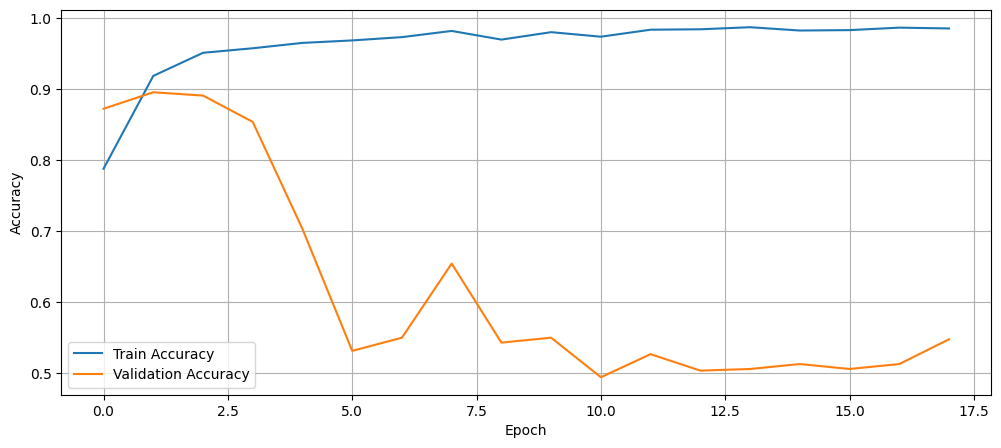

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

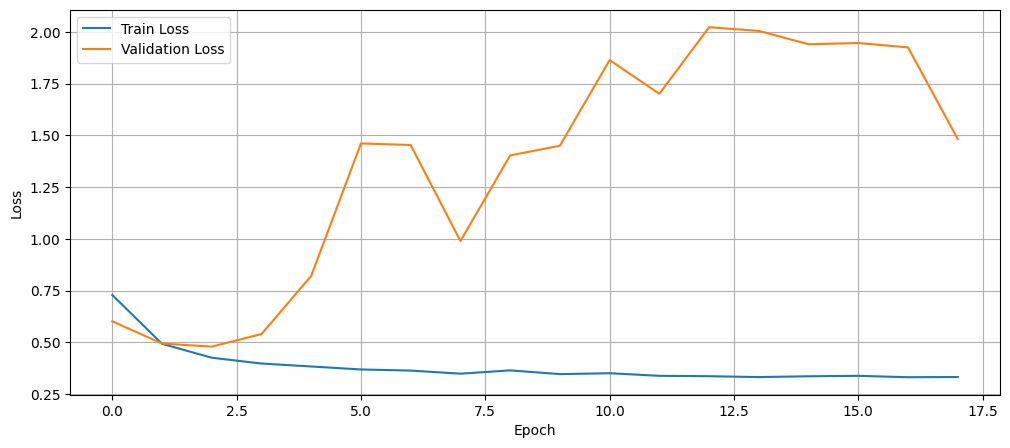

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history["loss"], label="Train Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Evaluation Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
Prediction Shape : (431, 3)

Evaluation Results
Accuracy : 0.8910
Precision: 0.8981
Recall   : 0.8910
F1 Score : 0.8769

Classification Report

                       precision    recall  f1-score   support

Potato___Early_blight     0.8728    0.9950    0.9299       200
 Potato___Late_blight     0.9077    0.8850    0.8962       200
     Potato___healthy     1.0000    0.2581    0.4103        31

             accuracy                         0.8910       431
            macro avg     0.9268    0.7127    0.7455       431
         weighted avg     0.8981    0.8910    0.8769       431



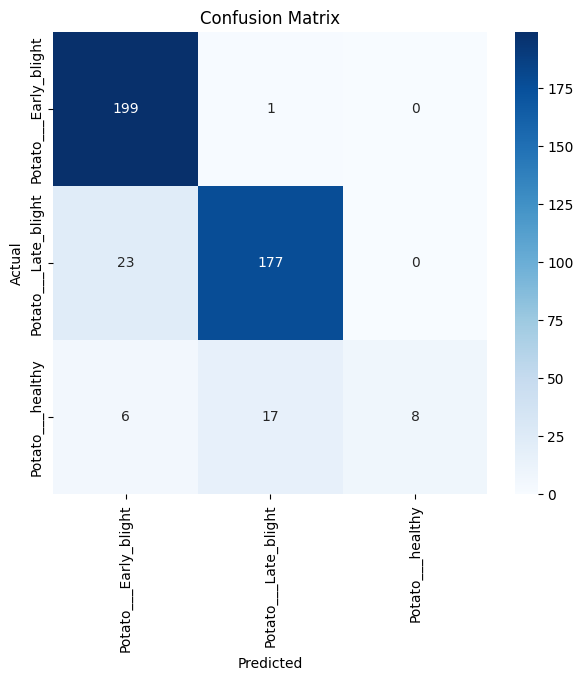

In [ ]:
# ==========================================================
# Predict on Test Set (Corrected)
# ==========================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict probabilities
pred_prob = model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

# Predicted class indices
y_pred = np.argmax(pred_prob, axis=1)

# True class indices
y_true = np.argmax(y_test, axis=1)

print("Prediction Shape :", pred_prob.shape)

# ==========================================================
# Metrics
# ==========================================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("\n==============================")
print("Evaluation Results")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_,
        digits=4
    )
)

# ==========================================================
# Confusion Matrix
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ==========================================================
# ROC, AUC, Precision-Recall, mAP
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

In [ ]:
# ==========================================================
# Predict Probabilities
# ==========================================================

pred_prob = model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_true = np.argmax(y_test, axis=1)

y_pred = np.argmax(pred_prob, axis=1)

print(pred_prob.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step
(431, 3)


In [ ]:
# ==========================================================
# One Hot Labels
# ==========================================================

num_classes = len(encoder.classes_)

y_test_onehot = y_test

print(y_test_onehot.shape)

(431, 3)


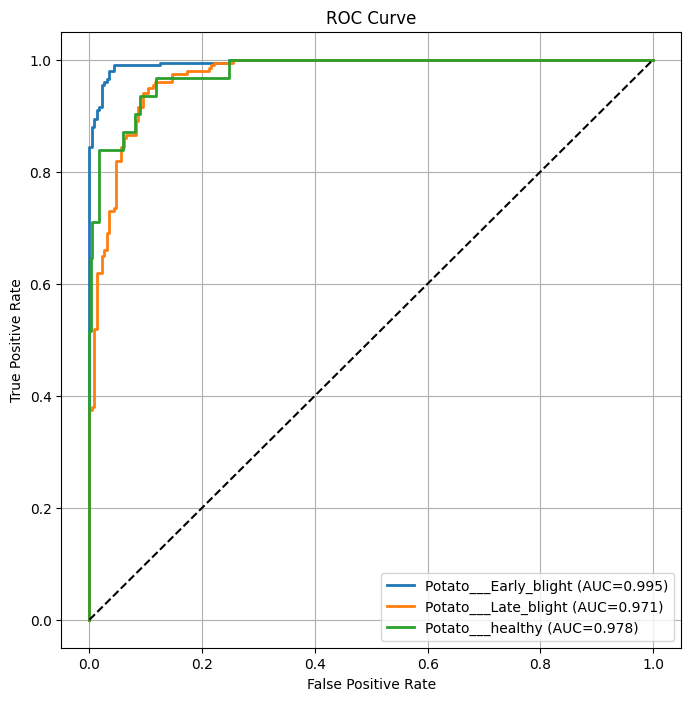

In [ ]:
# ==========================================================
# ROC Curve
# ==========================================================

plt.figure(figsize=(8,8))

roc_auc = {}

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(

        y_test_onehot[:, i],

        pred_prob[:, i]

    )

    roc_auc[i] = auc(fpr, tpr)

    plt.plot(

        fpr,

        tpr,

        lw=2,

        label=f"{encoder.classes_[i]} (AUC={roc_auc[i]:.3f})"

    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

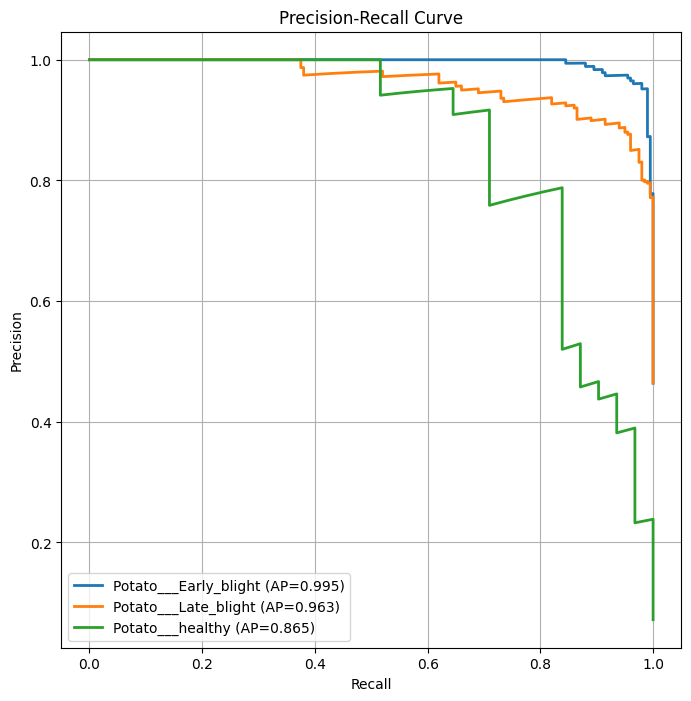

In [ ]:
# ==========================================================
# Precision Recall Curve
# ==========================================================

plt.figure(figsize=(8,8))

average_precision = {}

for i in range(num_classes):

    precision, recall, _ = precision_recall_curve(

        y_test_onehot[:,i],

        pred_prob[:,i]

    )

    average_precision[i] = average_precision_score(

        y_test_onehot[:,i],

        pred_prob[:,i]

    )

    plt.plot(

        recall,

        precision,

        lw=2,

        label=f"{encoder.classes_[i]} (AP={average_precision[i]:.3f})"

    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Mean Average Precision
# ==========================================================

mAP = np.mean(

    list(average_precision.values())

)

print("Mean Average Precision (mAP): {:.4f}".format(mAP))

Mean Average Precision (mAP): 0.9408


In [ ]:
# ==========================================================
# Individual AUC
# ==========================================================

print("\nAUC Scores\n")

for i in range(num_classes):

    print(

        encoder.classes_[i],

        ":",

        round(roc_auc[i],4)

    )


AUC Scores

Potato___Early_blight : 0.9955
Potato___Late_blight : 0.971
Potato___healthy : 0.9779


In [ ]:
# ==========================================================
# Save Metrics
# ==========================================================

metrics = {

    "Accuracy": accuracy,

    "Precision": precision_score(

        y_true,

        y_pred,

        average="weighted"

    ),

    "Recall": recall_score(

        y_true,

        y_pred,

        average="weighted"

    ),

    "F1": f1_score(

        y_true,

        y_pred,

        average="weighted"

    ),

    "mAP": mAP

}

for k, v in metrics.items():

    print(f"{k:12s}: {v:.4f}")

Accuracy    : 0.8910
Precision   : 0.8981
Recall      : 0.8910
F1          : 0.8769
mAP         : 0.9408


In [ ]:
# ==========================================================
# Save Results
# ==========================================================

import pandas as pd

df = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "mAP"

    ],

    "Value":[

        metrics["Accuracy"],

        metrics["Precision"],

        metrics["Recall"],

        metrics["F1"],

        metrics["mAP"]

    ]

})

df.to_csv(

    "ConViTX_Metrics.csv",

    index=False

)

print(df)

print("\nSaved as ConViTX_Metrics.csv")

      Metric     Value
0   Accuracy  0.890951
1  Precision  0.898144
2     Recall  0.890951
3   F1 Score  0.876890
4        mAP  0.940829

Saved as ConViTX_Metrics.csv


In [ ]:
# ==========================================================
# Grad-CAM Imports
# ==========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
# ==========================================================
# Check Layer Name
# ==========================================================

for layer in model.layers:

    print(layer.name)

input_layer
patches
patch_encoder
LN1_0
MHA_0
add
LN2_0
dense_3
dropout_1
dense_4
dropout_2
add_1
LN1_1
MHA_1
add_2
LN2_1
dense_5
dropout_4
dense_6
Conv1
dropout_5
bn_Conv1
add_3
Conv1_relu
LN1_2
expanded_conv_depthwise
MHA_2
expanded_conv_depthwise_BN
add_4
expanded_conv_depthwise_relu
LN2_2
expanded_conv_project
dense_7
expanded_conv_project_BN
dropout_7
block_1_expand
dense_8
block_1_expand_BN
dropout_8
block_1_expand_relu
add_5
block_1_pad
LN1_3
block_1_depthwise
MHA_3
block_1_depthwise_BN
add_6
block_1_depthwise_relu
LN2_3
block_1_project
dense_9
block_1_project_BN
dropout_10
block_2_expand
dense_10
block_2_expand_BN
dropout_11
block_2_expand_relu
add_7
block_2_depthwise
LN1_4
block_2_depthwise_BN
MHA_4
block_2_depthwise_relu
add_8
block_2_project
LN2_4
block_2_project_BN
dense_11
block_2_add
dropout_13
block_3_expand
dense_12
block_3_expand_BN
dropout_14
block_3_expand_relu
add_9
block_3_pad
LN1_5
block_3_depthwise
MHA_5
block_3_depthwise_BN
add_10
block_3_depthwise_relu
LN2_5
bl

In [ ]:
# ==========================================================
# GradCAM Model
# ==========================================================

last_conv_layer_name = "cam_layer1"

grad_model = tf.keras.models.Model(

    inputs=model.inputs,

    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]

)

print("GradCAM model ready.")

GradCAM model ready.


In [ ]:
# ==========================================================
# GradCAM Function
# ==========================================================

def make_gradcam_heatmap(img_array,
                         grad_model,
                         pred_index=None):

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:

            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(

        class_channel,

        conv_outputs

    )

    pooled_grads = tf.reduce_mean(

        grads,

        axis=(0,1,2)

    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= (

        tf.reduce_max(heatmap) + 1e-8

    )

    return heatmap.numpy()

In [ ]:
# ==========================================================
# Choose Image
# ==========================================================

index = np.random.randint(len(X_test))

img = X_test[index]

img_input = np.expand_dims(img, axis=0)

prediction = model.predict(img_input)

predicted = np.argmax(prediction)

actual = np.argmax(y_test[index])

print("Predicted :", encoder.classes_[predicted])

print("Actual    :", encoder.classes_[actual])

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
Predicted : Potato___Early_blight
Actual    : Potato___Early_blight


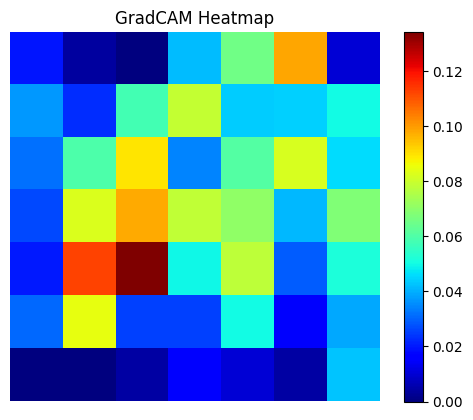

In [ ]:
# ==========================================================
# Generate Heatmap
# ==========================================================

heatmap = make_gradcam_heatmap(

    img_input,

    grad_model

)

plt.imshow(heatmap,cmap="jet")

plt.colorbar()

plt.title("GradCAM Heatmap")

plt.axis("off")

plt.show()

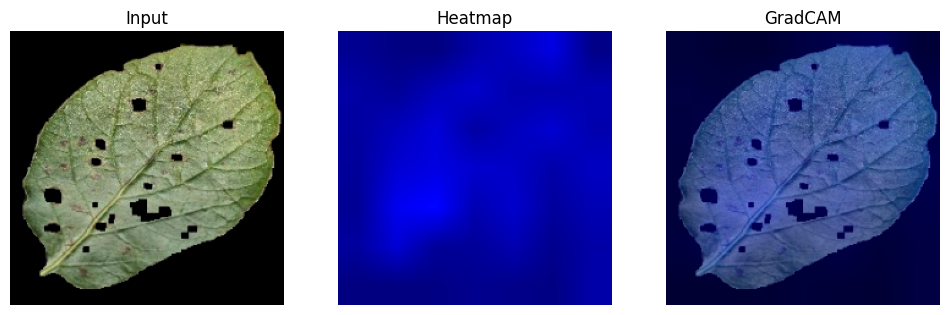

In [ ]:
# ==========================================================
# Overlay Heatmap
# ==========================================================

display_img = ((img + 1.0)/2.0)

display_img = np.clip(display_img,0,1)

heatmap = cv2.resize(

    heatmap,

    (224,224)

)

heatmap = np.uint8(

    255*heatmap

)

heatmap = cv2.applyColorMap(

    heatmap,

    cv2.COLORMAP_JET

)

overlay = cv2.addWeighted(

    np.uint8(display_img*255),

    0.6,

    heatmap,

    0.4,

    0

)

plt.figure(figsize=(12,4))

plt.subplot(131)

plt.imshow(display_img)

plt.title("Input")

plt.axis("off")

plt.subplot(132)

plt.imshow(cv2.cvtColor(heatmap,cv2.COLOR_BGR2RGB))

plt.title("Heatmap")

plt.axis("off")

plt.subplot(133)

plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))

plt.title("GradCAM")

plt.axis("off")

plt.show()

In [ ]:
# ==========================================================
# Save GradCAM
# ==========================================================

cv2.imwrite(

    "GradCAM_Result.png",

    overlay

)

print("Saved GradCAM_Result.png")

Saved GradCAM_Result.png
